In [1]:
import os
import numpy as np
from tqdm import tqdm 
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp

mpl.rc('figure', figsize=(12, 6))
mpl.rc('text', usetex = False)
mpl.rc('font', family = 'serif')
mpl.rc('font', size = '14')
mpl.rc('xtick', labelsize=14) 
mpl.rc('ytick', labelsize=14)
mpl.rcParams['mathtext.fontset'] = 'stix'

In [2]:
#Definimos las direcciones de los archivos
tlargo = True

if tlargo == False:
    #Tiempos cortos (eta_max = 100, N = 128, dt = 0.003)
    dir_m2phi2 = "./build_m2phi2/data/short/"
    dir_tanh2 = "./build_tanh2/data/short/"
    dir_starobinsky3 = "./build_starobinsky3/data/short/"

else:
    #Tiempos largos (eta_max = 900, N = 64, dt = 0.01)
    dir_m2phi2 = "./build_m2phi2/data/var_q/q_9600/"
    dir_tanh2 = "./build_tanh2/data/tanh2/m_1.46e13/M_2.435e19/"
    dir_starobinsky3 = "./build_starobinsky3/data/starobinsky3/m_1.46e13/M_2.435e19/"

# Buscamos las bandas de resonancia

# Scale factor $a(\tilde\eta)$

The file contains the following columns:

$\tilde\eta$ | $a$ | $a'$ | $\frac{a'}{a}$

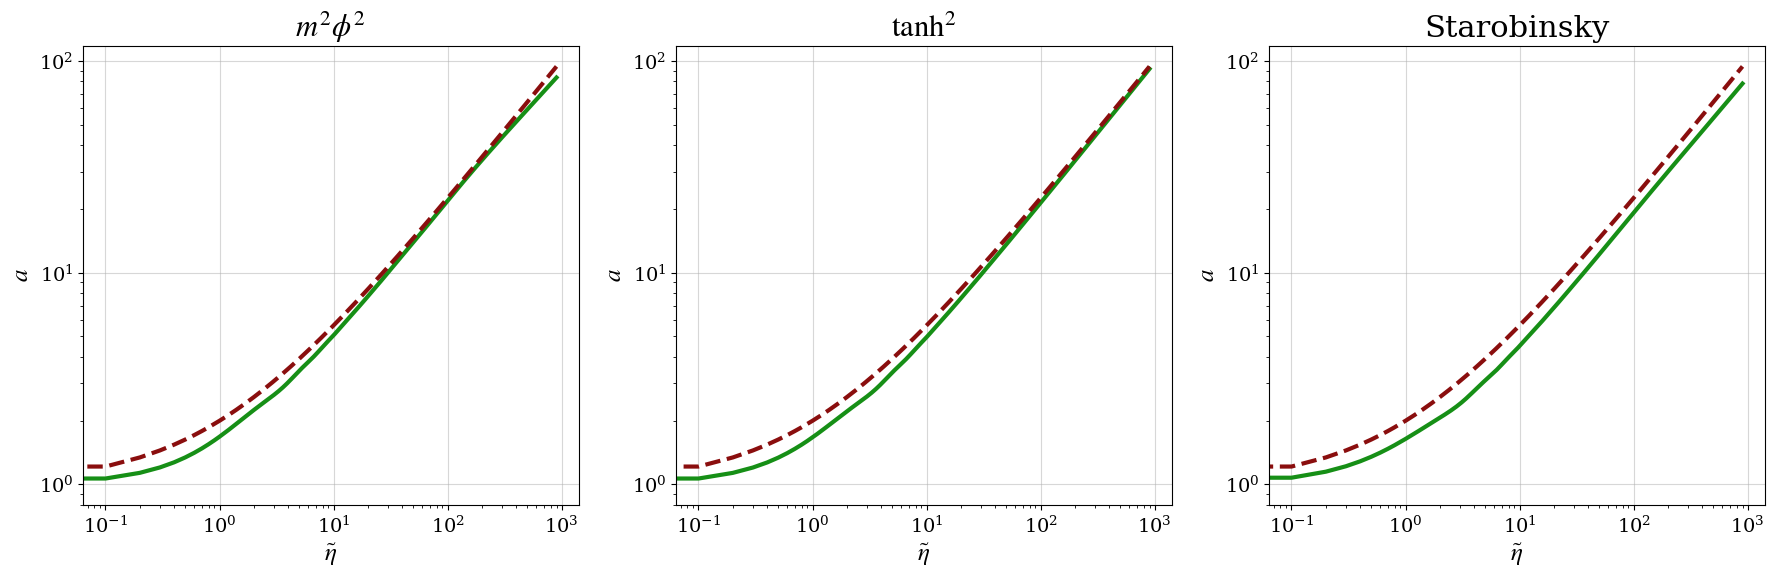

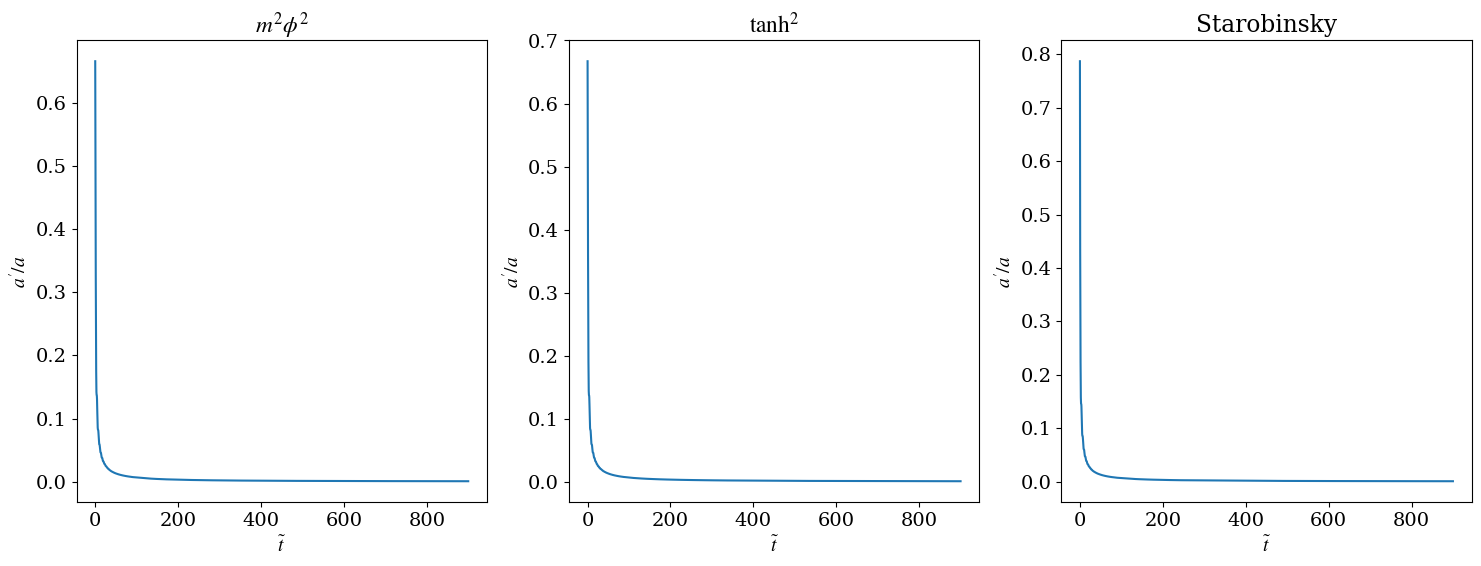

In [3]:
expansion = True

if expansion == True:
    # load the file in aDat
    aDat_m2phi2 = np.loadtxt(dir_m2phi2 + "average_scale_factor.txt")
    aDat_tanh2 = np.loadtxt(dir_tanh2 + "average_scale_factor.txt")
    aDat_starobinsky3 = np.loadtxt(dir_starobinsky3 + "average_scale_factor.txt")

    #plot a#plot a
    plt.figure(figsize=(18, 6))
    
    plt.subplot(1, 3, 1)
    plt.plot(aDat_m2phi2[:,0], aDat_m2phi2[:,1], color = "#168F16", lw = 3)
    plt.plot(aDat_m2phi2[:,0], aDat_m2phi2[:,0]**(2/3)+1, ls = "--", color = "#8a0e0e", lw = 3)
    plt.ylabel("$a$", fontsize = 18)
    plt.xlabel('$\\tilde\eta$', fontsize = 18)
    plt.title(r"$m^2 \phi^2$", fontsize = 22)
    plt.xscale('log')
    plt.yscale('log')
    plt.grid(alpha = 0.5)

    plt.subplot(1, 3, 2)
    plt.plot(aDat_tanh2[:,0], aDat_tanh2[:,1], color = "#168F16", lw = 3)
    plt.plot(aDat_tanh2[:,0], aDat_tanh2[:,0]**(2/3)+1, ls = "--", color = "#8a0e0e", lw = 3)
    plt.ylabel("$a$", fontsize = 18)
    plt.xlabel('$\\tilde\eta$', fontsize = 18)
    plt.title(r"$\tanh^2$", fontsize = 22)
    plt.xscale('log')
    plt.yscale('log')
    plt.grid(alpha = 0.5)

    plt.subplot(1, 3, 3)
    plt.plot(aDat_starobinsky3[:,0], aDat_starobinsky3[:,1], color = "#168F16", lw = 3)
    plt.plot(aDat_starobinsky3[:,0], aDat_starobinsky3[:,0]**(2/3)+1, ls = "--", color = "#8a0e0e", lw = 3)
    plt.ylabel("$a$", fontsize = 18)
    plt.xlabel('$\\tilde\eta$', fontsize = 18)
    plt.title(r"Starobinsky", fontsize = 22)
    plt.xscale('log')
    plt.yscale('log')
    plt.grid(alpha = 0.5)

    plt.tight_layout()
    plt.savefig("CosmoLattice_background_a_m2phi2tanh2Starobinsky.pdf", format = "pdf")


    #plot a'/a
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.plot(aDat_m2phi2[:,0], aDat_m2phi2[:,3])
    plt.ylabel(r"$a^\prime/a$")
    plt.xlabel(r'$\tilde t$')
    plt.title(r"$m^2 \phi^2$")

    plt.subplot(1, 3, 2)
    plt.plot(aDat_tanh2[:,0], aDat_tanh2[:,3])
    plt.ylabel(r"$a^\prime/a$")
    plt.xlabel(r'$\tilde t$')
    plt.title(r"$\tanh^2$")

    plt.subplot(1, 3, 3)
    plt.plot(aDat_starobinsky3[:,0], aDat_starobinsky3[:,3])
    plt.ylabel(r"$a^\prime/a$")
    plt.xlabel(r'$\tilde t$')
    plt.title(r"Starobinsky")
    
else:
    aDat_m2phi2 = None
    aDat_tanh2 = None
    aDat_starobinsky3 = None

# Volume average of fields

The files for the averages of the scalar fields contain the following columns:

$\eta$ | $\langle \tilde\phi_n \rangle$ | $\langle \tilde\phi'_n \rangle$ | $\langle \tilde\phi^2_n \rangle$ | $\langle \tilde\phi^{'2}_n \rangle$ | $\mathrm{rms}(\tilde\phi_n) $ | $\mathrm{rms}(\tilde\phi'_n) $

In [4]:
# Define a function for the plots, as we are gonna do 
# the same for both fields
def plot_fld(fldDat, fldNum="", aDat=None):
    plt.plot(fldDat[:,0], fldDat[:,1])
    plt.xlabel("$\\tilde\eta$")
    plt.ylabel("$\langle\phi_"+ fldNum +"\\rangle$")
    
    if aDat is not None:
        plt.plot(fldDat[:,0], aDat[:,1] * fldDat[:,1])
        plt.xlabel("$\\tilde\eta$")
        plt.ylabel("$a\cdot\langle\phi_"+ fldNum +" \\rangle$")

## Field $0$ (inflaton)

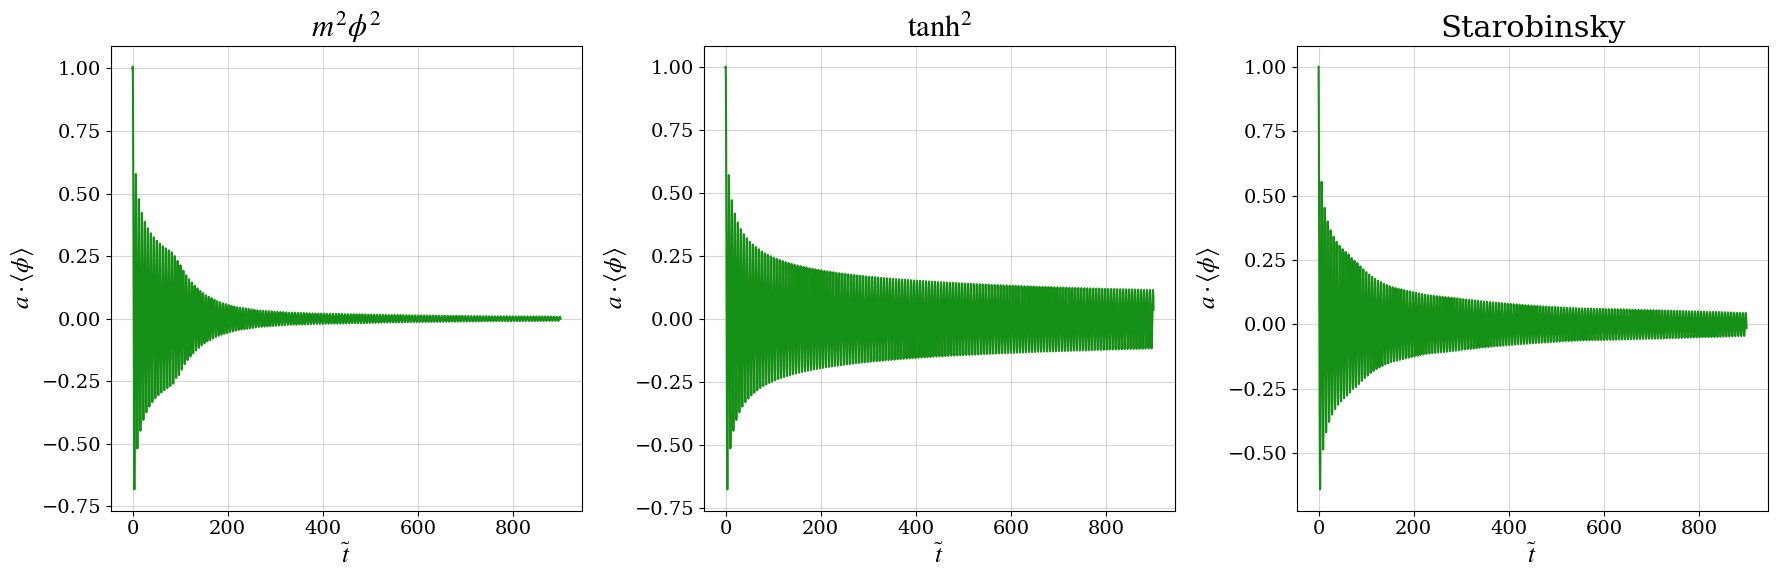

In [5]:
infDat_m2phi2 = np.loadtxt(dir_m2phi2 + "average_scalar_0.txt")
infDat_tanh2 = np.loadtxt(dir_tanh2 + "average_scalar_0.txt")
infDat_starobinsky3 = np.loadtxt(dir_starobinsky3 + "average_scalar_0.txt")

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.plot(infDat_m2phi2[:,0], aDat_m2phi2[:,1] * infDat_m2phi2[:,1], color = "#168F16")
plt.xlabel("$\\tilde t$", fontsize = 18)
plt.ylabel(r"$a\cdot\langle \phi \rangle$", fontsize = 18)
plt.title(r'$m^2 \phi^2$', fontsize = 22)
plt.grid(alpha = 0.5)

plt.subplot(1, 3, 2)
plt.plot(infDat_tanh2[:,0], aDat_tanh2[:,1] * infDat_tanh2[:,1], color = "#168F16")
plt.xlabel("$\\tilde t$", fontsize = 18)
plt.ylabel(r"$a\cdot\langle \phi \rangle$", fontsize = 18)
plt.title(r'$\tanh^2$', fontsize = 22)
plt.grid(alpha = 0.5)

plt.subplot(1, 3, 3)
plt.plot(infDat_starobinsky3[:,0], aDat_starobinsky3[:,1] * infDat_starobinsky3[:,1], color = "#168F16")
plt.xlabel("$\\tilde t$", fontsize = 18)
plt.ylabel(r"$a\cdot\langle \phi \rangle$", fontsize = 18)
plt.title(r"Starobinsky", fontsize = 22)
plt.grid(alpha = 0.5)

plt.tight_layout()
plt.savefig("CosmoLattice_background_phi_m2phi2tanh2Starobinsky.pdf", format = "pdf")

## Field $1$ (daughter field)

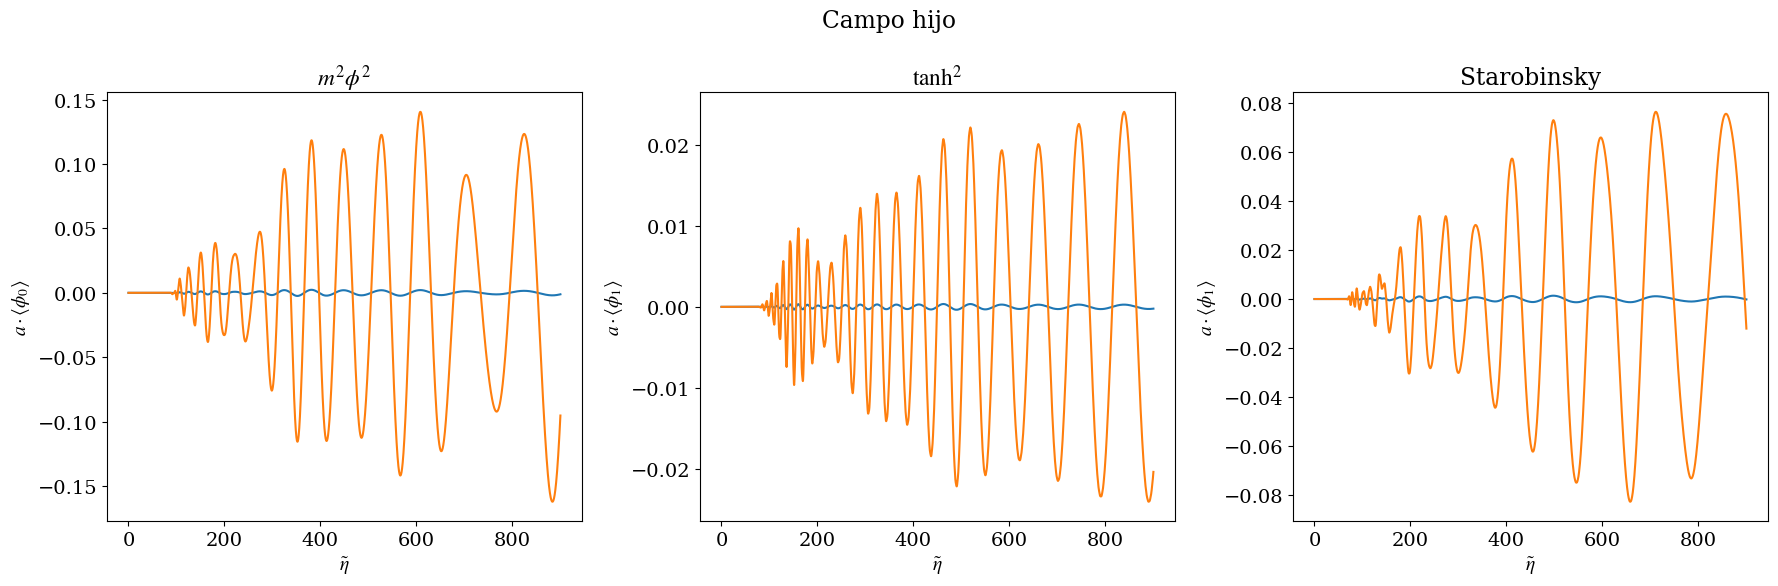

In [6]:
infDat_m2phi2 = np.loadtxt(dir_m2phi2 + "average_scalar_1.txt")
infDat_tanh2 = np.loadtxt(dir_tanh2 + "average_scalar_1.txt")
infDat_starobinsky3 = np.loadtxt(dir_starobinsky3 + "average_scalar_1.txt")

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plot_fld(infDat_m2phi2,"0",aDat_m2phi2)
plt.title(r'$m^2 \phi^2$')

plt.subplot(1, 3, 2)
plot_fld(infDat_tanh2,"1",aDat_tanh2)
plt.title(r'$\tanh^2$')

plt.subplot(1, 3, 3)
plot_fld(infDat_starobinsky3,"1",aDat_starobinsky3)
plt.title(r"Starobinsky")

plt.suptitle(r'Campo hijo')
plt.tight_layout()
plt.show()

# "Energy conservation" (the $1^{st}$ Friedmann's equation is satisfied)

The file  that checks the first Friedmann's equation contains

$\tilde\eta$ | $\frac{\langle LHS - RHS\rangle}{\langle LHS + RHS\rangle}$ | $\langle LHS \rangle$ | $\langle RHS \rangle$ 

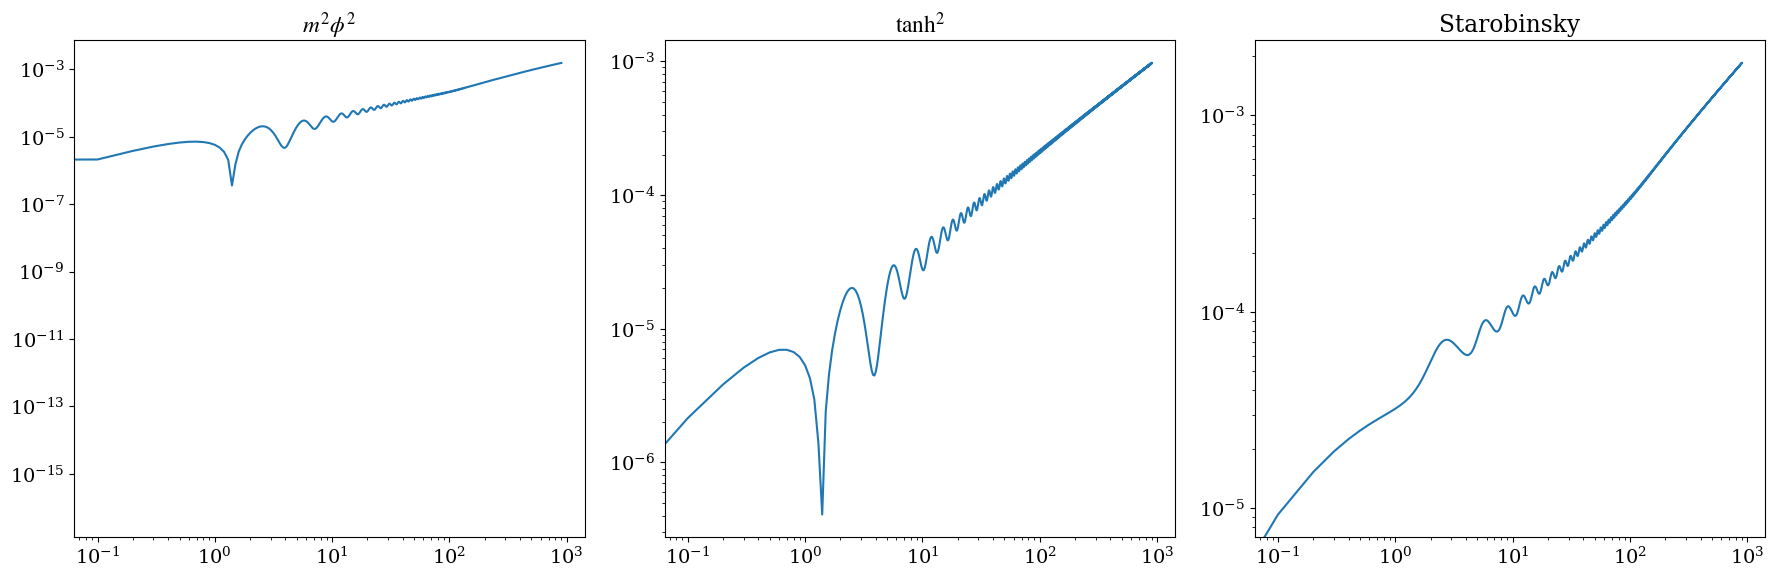

In [7]:
enConsDat_m2phi2 = np.loadtxt(dir_m2phi2 + "average_energy_conservation.txt")
enConsDat_tanh2 = np.loadtxt(dir_tanh2 + "average_energy_conservation.txt")
enConsDat_starobinsky3 = np.loadtxt(dir_starobinsky3 + "average_energy_conservation.txt")

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.plot(enConsDat_m2phi2[:,0], np.abs(enConsDat_m2phi2[:,1]))
plt.title(r"$m^2 \phi^2$")
plt.yscale('log')
plt.xscale('log')

plt.subplot(1, 3, 2)
plt.plot(enConsDat_tanh2[:,0], np.abs(enConsDat_tanh2[:,1]))
plt.title(r"$\tanh^2$")
plt.yscale('log')
plt.xscale('log')

plt.subplot(1, 3, 3)
plt.plot(enConsDat_starobinsky3[:,0], np.abs(enConsDat_starobinsky3[:,1]))
plt.title(r"Starobinsky")
plt.yscale('log')
plt.xscale('log')

plt.tight_layout()
plt.show()

# Energy densities

The file with the energy densities contains

$\tilde\eta$ | $\tilde E_K^{(0)}$ | $\tilde E_G^{(0)}$ |$\dots$| $\tilde E_K^{(N_s-1)}$ | $\tilde E_G^{(N_s-1)}$ |  $\tilde E_V^{(0)}$ | $\dots$ |  $\tilde E_V^{(N_p-1)}$ | $\langle \tilde \rho \rangle$

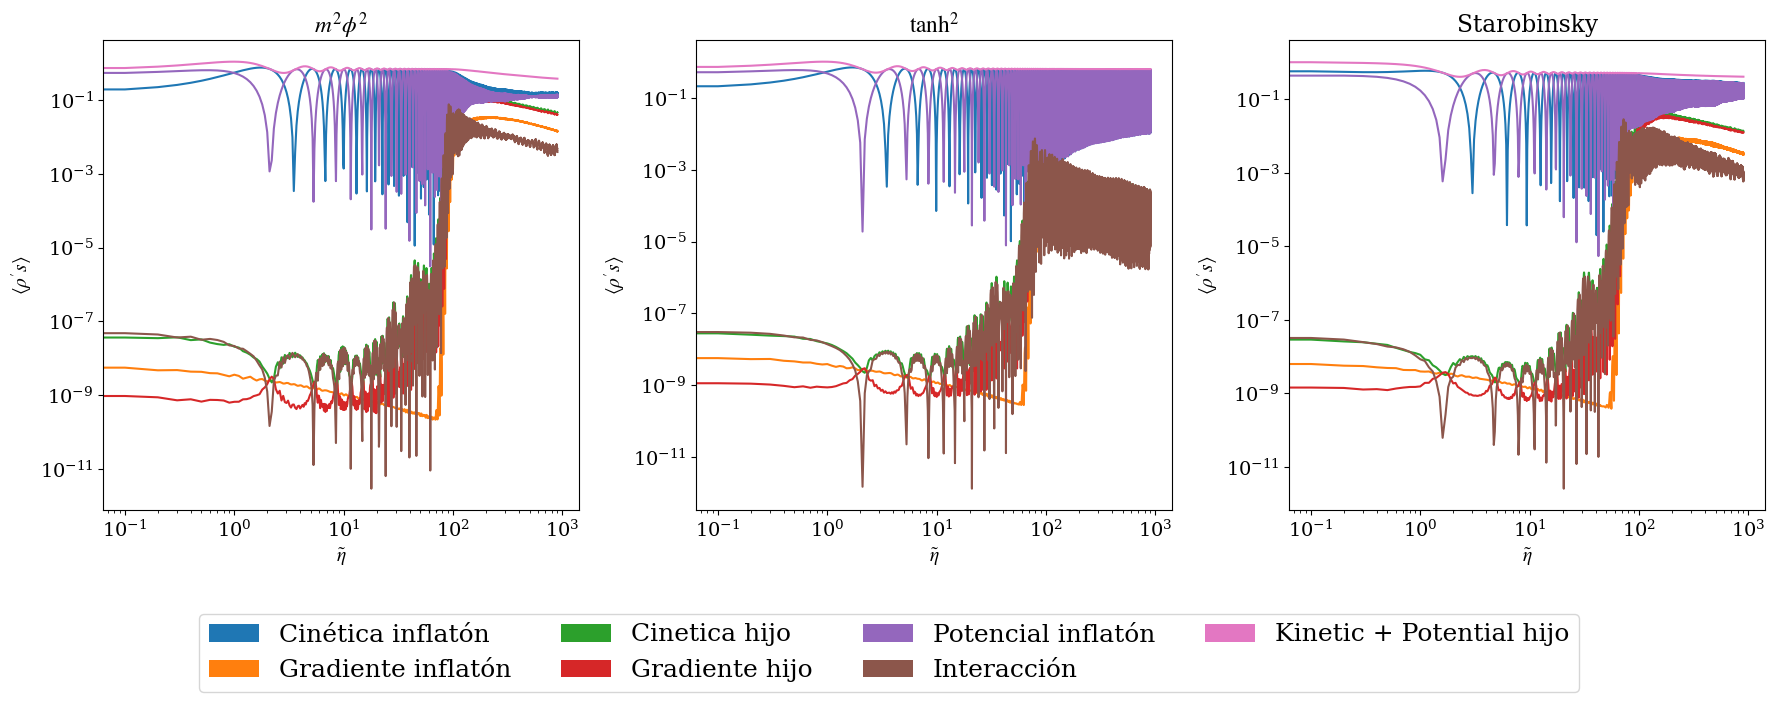

In [8]:
enDat_m2phi2 = np.loadtxt(dir_m2phi2 + "average_energies.txt")
enDat_tanh2 = np.loadtxt(dir_tanh2 + "average_energies.txt")
enDat_starobinsky3 = np.loadtxt(dir_starobinsky3 + "average_energies.txt")

nColumns_m2phi2 = np.shape(enDat_m2phi2)[1]
nColumns_tanh2 = np.shape(enDat_tanh2)[1]
nColumns_starobinsky3 = np.shape(enDat_starobinsky3)[1]

# set explicitly different colors, so we know who is who
label = ["Cinética inflatón", "Gradiente inflatón", "Cinetica hijo", "Gradiente hijo", "Potencial inflatón", "Interacción", "Kinetic + Potential hijo"]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink"]

fig = plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
for i in range(1,nColumns_m2phi2):
    plt.plot(enDat_m2phi2[:,0], enDat_m2phi2[:,i]*aDat_m2phi2[:,1]**3, color = colors[i-1])
plt.yscale('log')
plt.xscale('log')
plt.xlabel("$\\tilde \eta$")
plt.ylabel("$\langle \\rho's\\rangle$")
plt.title(r"$m^2 \phi^2$")

plt.subplot(1, 3, 2)
for i in range(1,nColumns_tanh2):
    plt.plot(enDat_tanh2[:,0], enDat_tanh2[:,i]*aDat_tanh2[:,1]**3, color = colors[i-1])
plt.yscale('log')
plt.xscale('log')
plt.xlabel("$\\tilde \eta$")
plt.ylabel("$\langle \\rho's\\rangle$")
plt.title(r"$\tanh^2$")

plt.subplot(1, 3, 3)
for i in range(1,nColumns_starobinsky3):
    plt.plot(enDat_starobinsky3[:,0], enDat_starobinsky3[:,i]*aDat_starobinsky3[:,1]**3, color = colors[i-1])
plt.yscale('log')
plt.xscale('log')
plt.xlabel("$\\tilde \eta$")
plt.ylabel("$\langle \\rho's\\rangle$")
plt.title(r"Starobinsky")

plt.tight_layout()

# Crear leyenda general con los colores
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], label=label[i]) for i in range(len(label))]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=18)

plt.show()

# Spectra

Spectra output varies depending on the option. The default one generates a txt file with the following columns:

$\tilde k$ | $\tilde\Delta_{\tilde\phi}$ | $\tilde\Delta_{\tilde\phi'}$ | $\tilde n_{\tilde\phi}$ | bin multiplicity

In [9]:
def load_spectrum(filename, comment = '#'):
    # The next few lines open the file and count
    # how many bins in one spectrum
    file = open(filename)
    nBins = 0
    # read first line
    line = file.readline()
    # while no blank we continue
    while line != "\n":
        # if not a comment line (header for instance)
        # we count one line
        if(line[0] != comment):
            nBins +=1
        # read next line
        line = file.readline()
    file.close()

    # now we know nBins. We still need to actually read the data.
    fileSp = np.loadtxt(filename, comments=comment)

    # find how many spectra are in the files
    nSpectra = len(fileSp) / nBins

    return fileSp, int(nBins), int(nSpectra)


def plot_spectrum(spectra, column, nBins, nSpectra, colormap='plasma'):
    colors = plt.get_cmap(colormap)
    norm = plt.Normalize(vmin=0, vmax=(nSpectra-1)*3)
    sm = plt.cm.ScalarMappable(cmap=colors, norm=norm)
    sm.set_array([])

    for i in range(nSpectra):
        plt.plot(
            spectra[i*nBins:(i+1)*nBins, 0],
            spectra[i*nBins:(i+1)*nBins, column],
            color=colors(i/nSpectra)
        )
    plt.xscale('log')
    plt.yscale('log')
    plt.grid(True, which="both", ls="--")
    plt.xlabel('$\\tilde k$', fontsize=20, labelpad=5)

    # Agrega la barra de colores asociada al eje actual
    cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.02)
    cbar.set_label(r'$t$', fontsize=20, rotation=10)
    cbar.ax.tick_params(labelsize=16)

## Inflaton

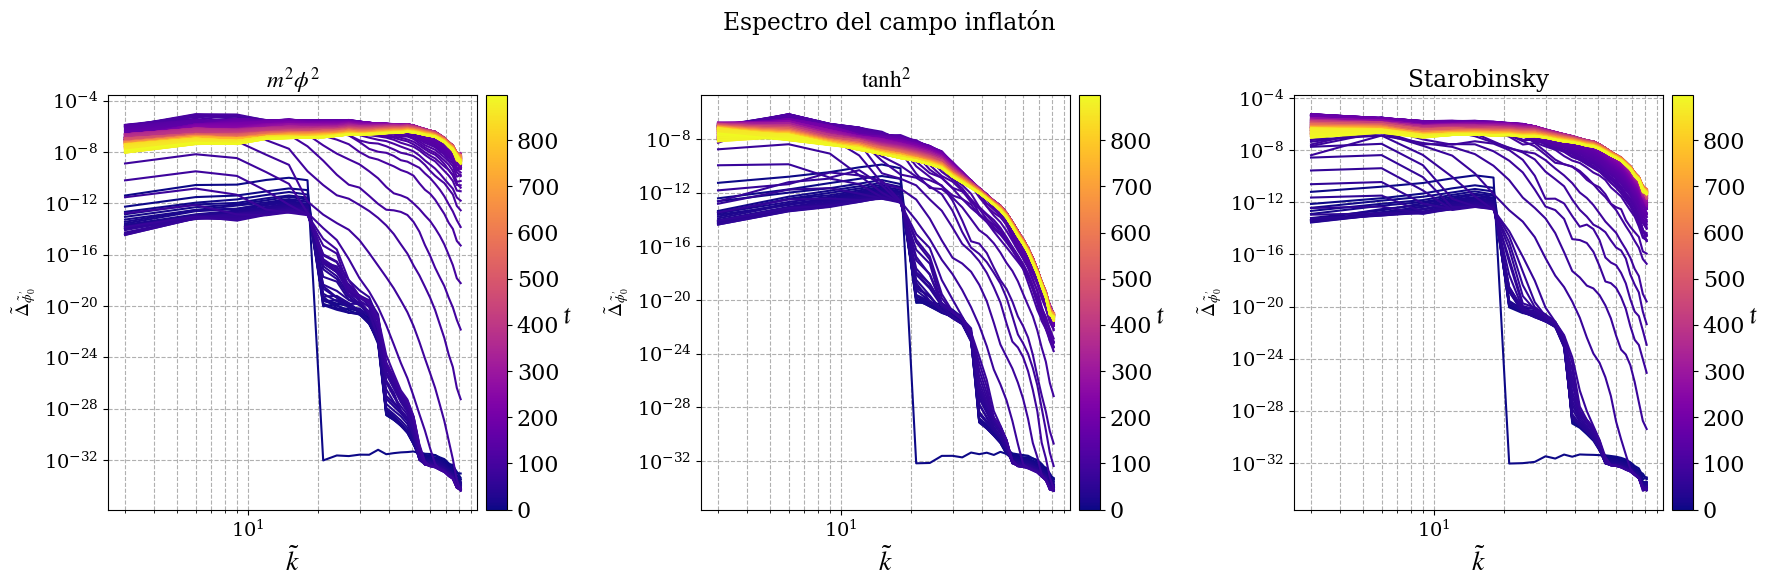

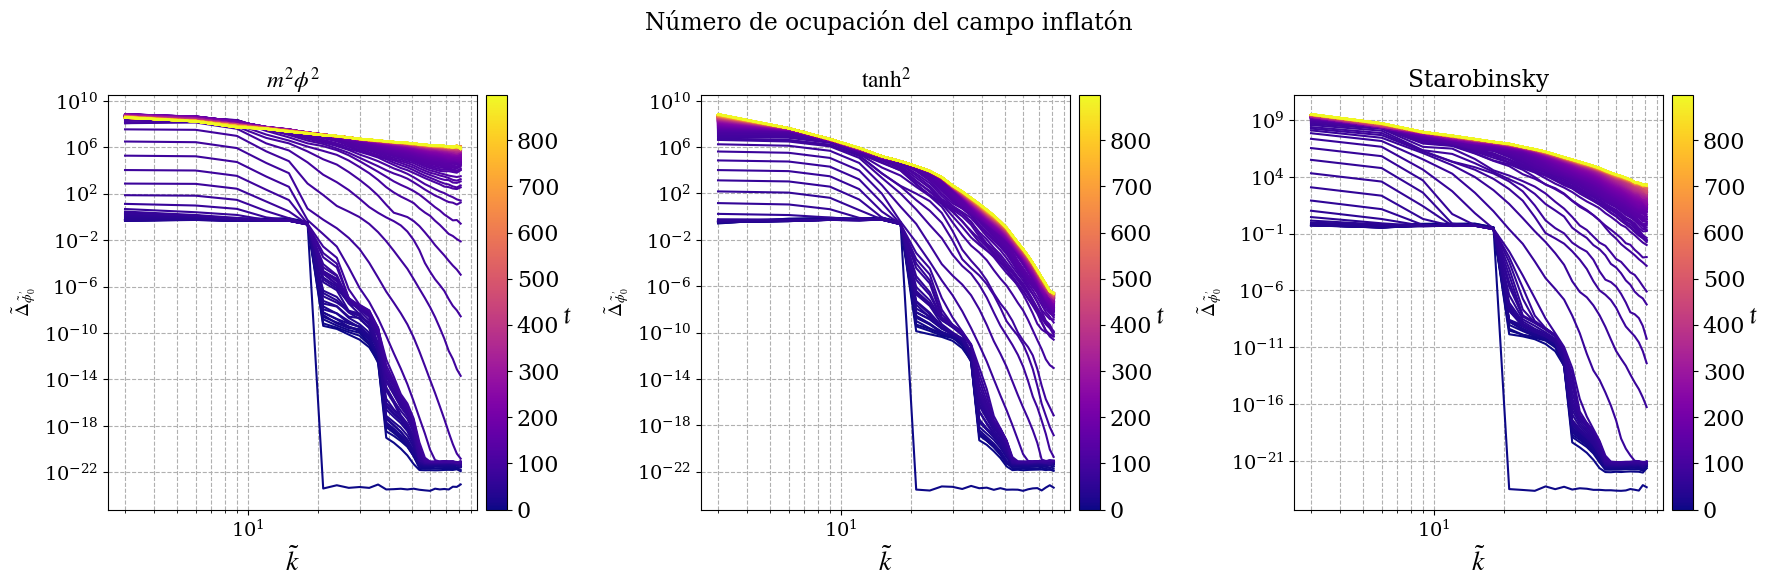

In [10]:
infSp_m2phi2, nBins_m2phi2, nSpectra_m2phi2 = load_spectrum(dir_m2phi2 + "spectra_scalar_0.txt")
infSp_tanh2, nBins_tanh2, nSpectra_tanh2 = load_spectrum(dir_tanh2 + "spectra_scalar_0.txt")
infSp_starobinsky3, nBins_starobinsky3, nSpectra_starobinsky3 = load_spectrum(dir_starobinsky3 + "spectra_scalar_0.txt")

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plot_spectrum(infSp_m2phi2, 1,  nBins_m2phi2, nSpectra_m2phi2)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'$m^2 \phi^2$')

plt.subplot(1, 3, 2)
plot_spectrum(infSp_tanh2, 1,  nBins_tanh2, nSpectra_tanh2)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'$\tanh^2$')

plt.subplot(1, 3, 3)
plot_spectrum(infSp_starobinsky3, 1,  nBins_starobinsky3, nSpectra_starobinsky3)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Starobinsky')

plt.suptitle(r'Espectro del campo inflatón')
plt.tight_layout()
plt.show()


plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plot_spectrum(infSp_m2phi2, 3,  nBins_m2phi2, nSpectra_m2phi2)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'$m^2 \phi^2$')

plt.subplot(1, 3, 2)
plot_spectrum(infSp_tanh2, 3,  nBins_tanh2, nSpectra_tanh2)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'$\tanh^2$')

plt.subplot(1, 3, 3)
plot_spectrum(infSp_starobinsky3, 3,  nBins_starobinsky3, nSpectra_starobinsky3)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Starobinsky')

plt.suptitle(r'Número de ocupación del campo inflatón')
plt.tight_layout()
plt.show()

## Daughter field

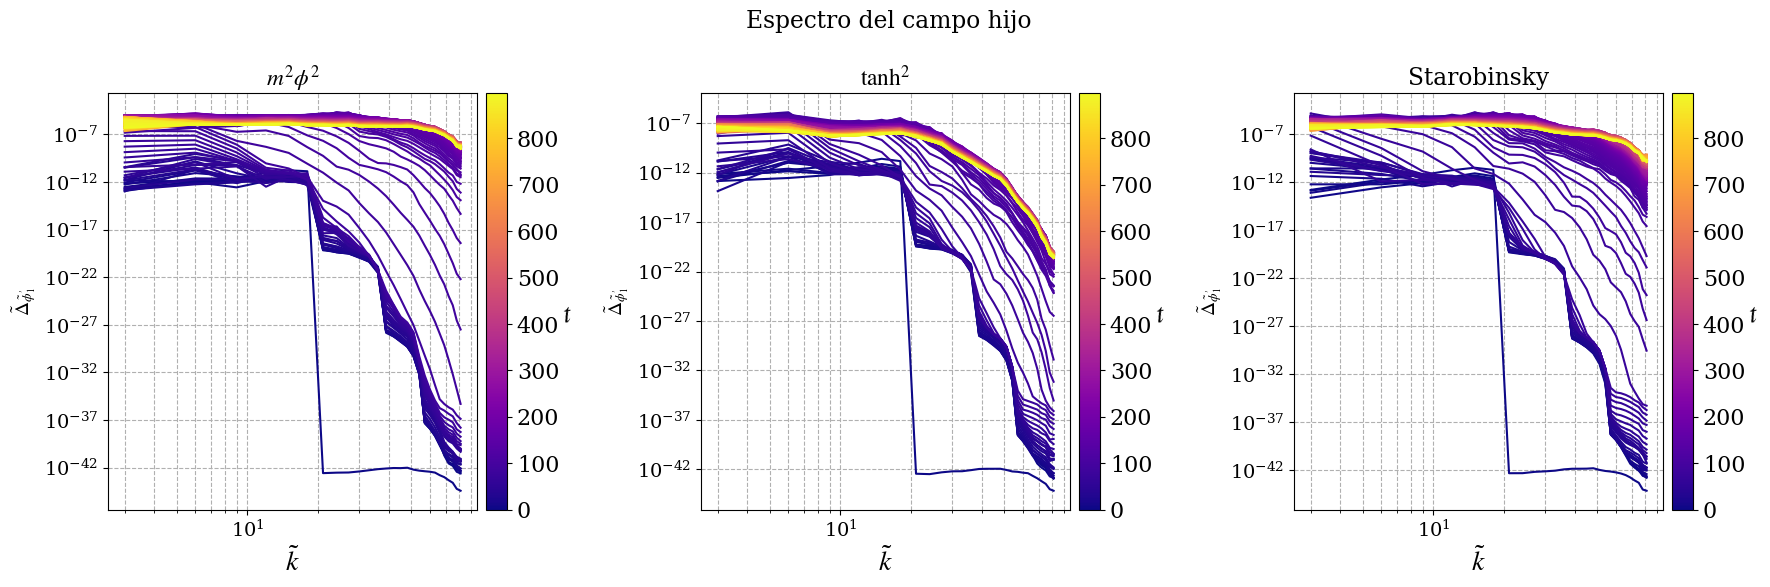

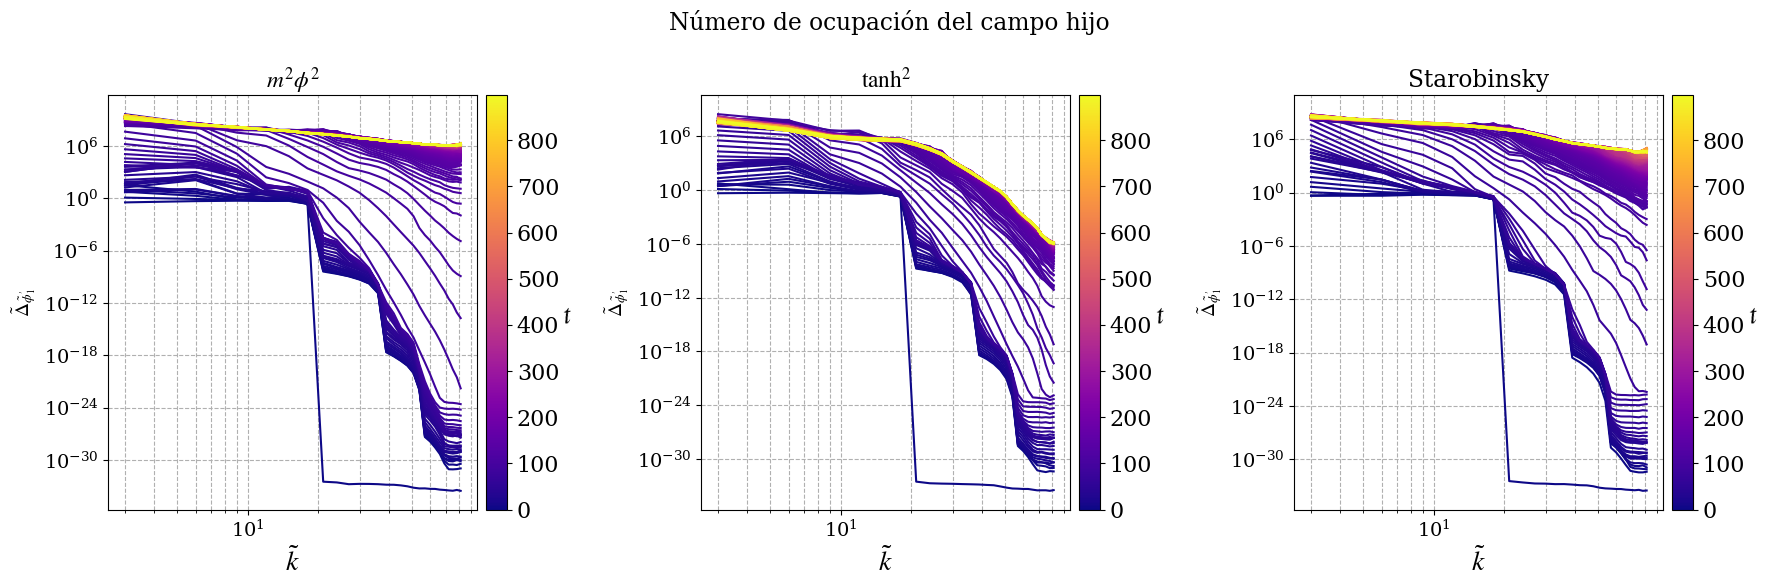

In [11]:
infSp_m2phi2, nBins_m2phi2, nSpectra_m2phi2 = load_spectrum(dir_m2phi2 + "spectra_scalar_1.txt")
infSp_tanh2, nBins_tanh2, nSpectra_tanh2 = load_spectrum(dir_tanh2 + "spectra_scalar_1.txt")
infSp_starobinsky3, nBins_starobinsky3, nSpectra_starobinsky3 = load_spectrum(dir_starobinsky3 + "spectra_scalar_1.txt")

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plot_spectrum(infSp_m2phi2, 1,  nBins_m2phi2, nSpectra_m2phi2)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_1\'}$')
plt.title(r'$m^2 \phi^2$')

plt.subplot(1, 3, 2)
plot_spectrum(infSp_tanh2, 1,  nBins_tanh2, nSpectra_tanh2)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_1\'}$')
plt.title(r'$\tanh^2$')

plt.subplot(1, 3, 3)
plot_spectrum(infSp_starobinsky3, 1,  nBins_starobinsky3, nSpectra_starobinsky3)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_1\'}$')
plt.title(r'Starobinsky')

plt.suptitle(r'Espectro del campo hijo')
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plot_spectrum(infSp_m2phi2, 3,  nBins_m2phi2, nSpectra_m2phi2)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_1\'}$')
plt.title(r'$m^2 \phi^2$')

plt.subplot(1, 3, 2)
plot_spectrum(infSp_tanh2, 3,  nBins_tanh2, nSpectra_tanh2)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_1\'}$')
plt.title(r'$\tanh^2$')

plt.subplot(1, 3, 3)
plot_spectrum(infSp_starobinsky3, 3,  nBins_starobinsky3, nSpectra_starobinsky3)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_1\'}$')
plt.title(r'Starobinsky')

plt.suptitle(r'Número de ocupación del campo hijo')
plt.tight_layout()
plt.show()

# GWs

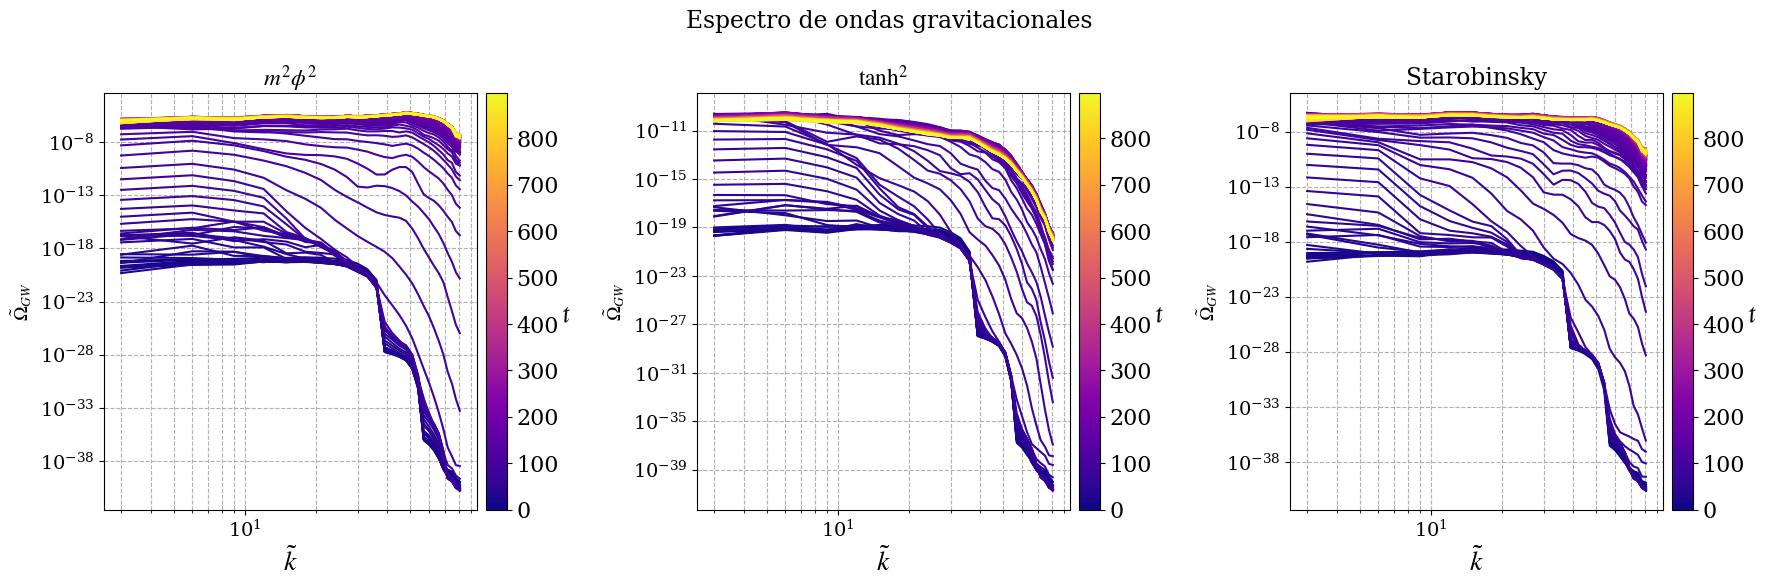

In [12]:
gwSp_m2phi2, nBins_m2phi2, nSpectra_m2phi2 = load_spectrum(dir_m2phi2 + "spectra_gws.txt")
gwSp_tanh2, nBins_tanh2, nSpectra_tanh2 = load_spectrum(dir_tanh2 + "spectra_gws.txt")
gwSp_starobinsky3, nBins_starobinsky3, nSpectra_starobinsky3 = load_spectrum(dir_starobinsky3 + "spectra_gws.txt")

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plot_spectrum(gwSp_m2phi2, 1,  nBins_m2phi2, nSpectra_m2phi2)
plt.ylabel('$\\tilde\Omega_{GW}$');
plt.title(r'$m^2 \phi^2$')

plt.subplot(1, 3, 2)
plot_spectrum(gwSp_tanh2, 1,  nBins_tanh2, nSpectra_tanh2)
plt.ylabel('$\\tilde\Omega_{GW}$');
plt.title(r'$\tanh^2$')

plt.subplot(1, 3, 3)
plot_spectrum(gwSp_starobinsky3, 1,  nBins_starobinsky3, nSpectra_starobinsky3)
plt.ylabel('$\\tilde\Omega_{GW}$');
plt.title(r'Starobinsky')

plt.suptitle(r'Espectro de ondas gravitacionales')
plt.tight_layout()
plt.show()

In [13]:
def integrate_spectrum(spectrum, nBins, nSpectra):
    total_energy = []
    for i in range(nSpectra):
        energy = np.trapezoid(spectrum[i*nBins:(i+1)*nBins, 1], spectrum[i*nBins:(i+1)*nBins, 0])
        total_energy.append(energy)
    return total_energy

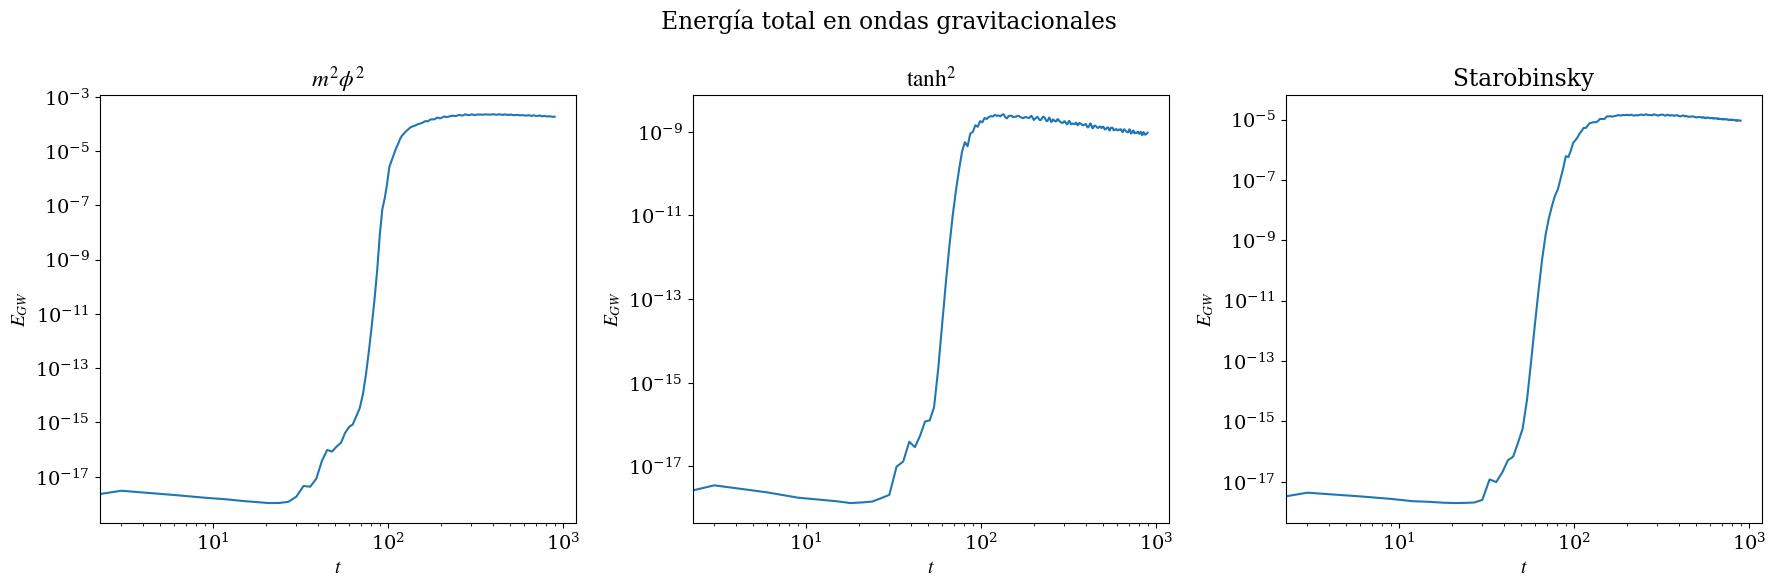

In [14]:
E_m2phi2 = integrate_spectrum(gwSp_m2phi2, nBins_m2phi2, nSpectra_m2phi2)
E_tanh2 = integrate_spectrum(gwSp_tanh2, nBins_tanh2, nSpectra_tanh2)
E_starobinsky3 = integrate_spectrum(gwSp_starobinsky3, nBins_starobinsky3, nSpectra_starobinsky3)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.plot(np.arange(nSpectra_m2phi2)*3, E_m2phi2)
plt.yscale('log')
plt.xscale('log') 
plt.xlabel(r'$t$')
plt.ylabel(r'$E_{GW}$')
plt.title(r'$m^2 \phi^2$')

plt.subplot(1, 3, 2)
plt.plot(np.arange(nSpectra_tanh2)*3, E_tanh2)
plt.yscale('log')
plt.xscale('log') 
plt.xlabel(r'$t$')
plt.ylabel(r'$E_{GW}$')
plt.title(r'$\tanh^2$')

plt.subplot(1, 3, 3)
plt.plot(np.arange(nSpectra_starobinsky3)*3, E_starobinsky3)
plt.yscale('log')
plt.xscale('log') 
plt.xlabel(r'$t$')
plt.ylabel(r'$E_{GW}$')
plt.title(r'Starobinsky')

plt.suptitle(r'Energía total en ondas gravitacionales')
plt.tight_layout()
plt.show()

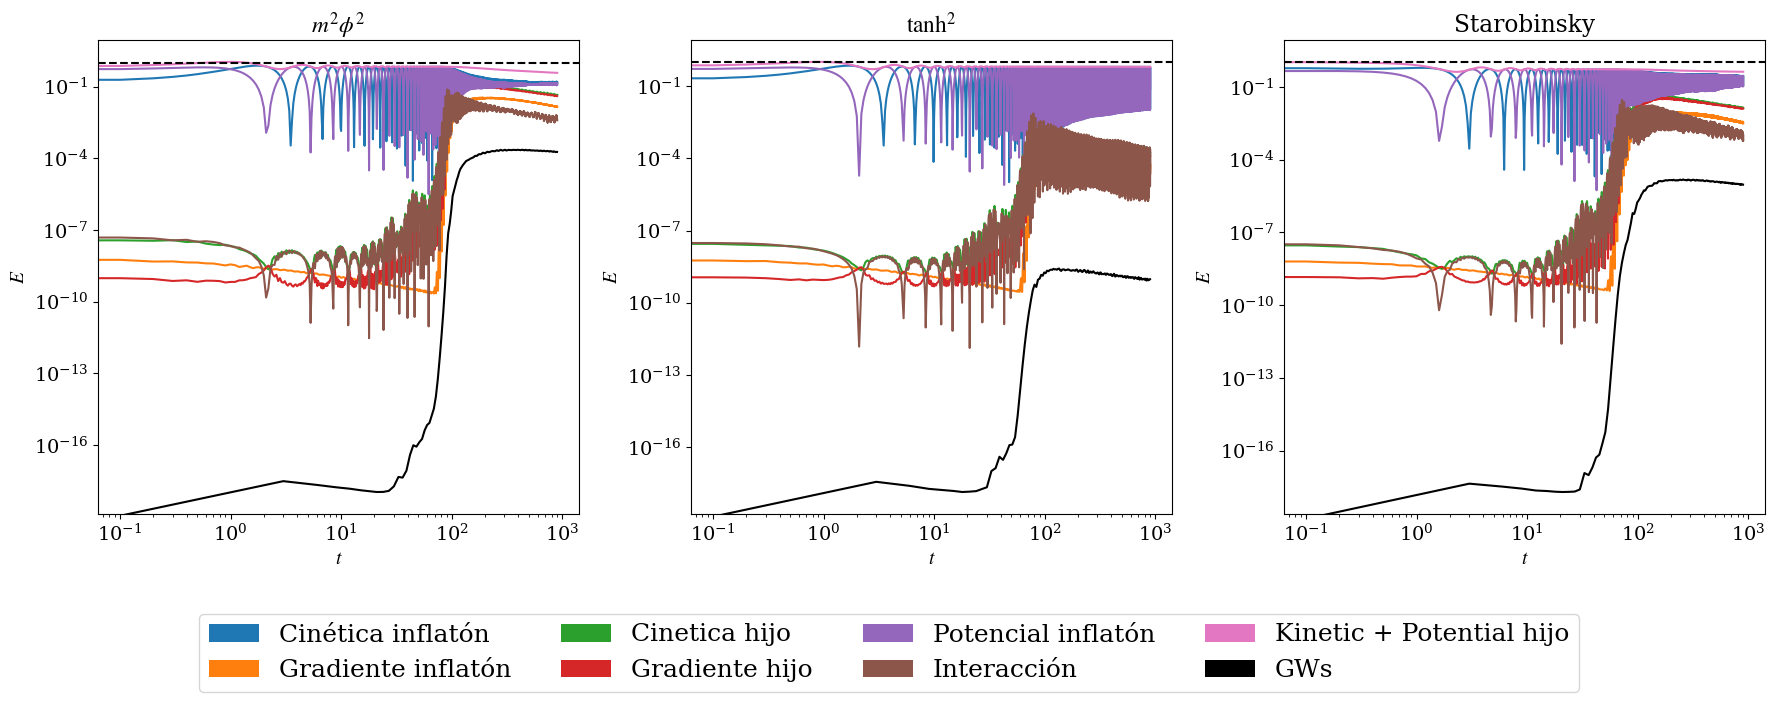

In [15]:
fig = plt.figure(figsize=(18, 6))

label = ["Cinética inflatón", "Gradiente inflatón", "Cinetica hijo", "Gradiente hijo", "Potencial inflatón", "Interacción", "Kinetic + Potential hijo", "GWs"]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "black"]

plt.subplot(1, 3, 1)
for i in range(1,nColumns_m2phi2):
    plt.plot(enDat_m2phi2[:,0], enDat_m2phi2[:,i]*aDat_m2phi2[:,1]**3, color = colors[i-1])
plt.plot(np.arange(nSpectra_m2phi2)*3, E_m2phi2, color = 'black')
plt.axhline(y = 1, ls = "--", color = "black")
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$t$')
plt.ylabel(r'$E$')
plt.title(r'$m^2 \phi^2$')

plt.subplot(1, 3, 2)
for i in range(1,nColumns_tanh2):
    plt.plot(enDat_tanh2[:,0], enDat_tanh2[:,i]*aDat_tanh2[:,1]**3, color = colors[i-1])
plt.plot(np.arange(nSpectra_tanh2)*3, E_tanh2, color = 'black')
plt.axhline(y = 1, ls = "--", color = "black")
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$t$')
plt.ylabel(r'$E$')
plt.title(r'$\tanh^2$')

plt.subplot(1, 3, 3)
for i in range(1,nColumns_starobinsky3):
    plt.plot(enDat_starobinsky3[:,0], enDat_starobinsky3[:,i]*aDat_starobinsky3[:,1]**3, color = colors[i-1])
plt.plot(np.arange(nSpectra_starobinsky3)*3, E_starobinsky3, color = 'black')
plt.axhline(y = 1, ls = "--", color = "black")
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$t$')
plt.ylabel(r'$E$')
plt.title(r'Starobinsky')

plt.tight_layout()

# Crear leyenda general con los colores
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], label=label[i]) for i in range(len(label))]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=18)

plt.show()